In [1]:
import pandas as pd
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent
MOVIELENS_RAW_DIR = PROJECT_ROOT / "data" / "raw" / "movielens"

MOVIES_PATH = MOVIELENS_RAW_DIR / "movies.csv"
RATINGS_PATH = MOVIELENS_RAW_DIR / "ratings.csv"
LINKS_PATH = MOVIELENS_RAW_DIR / "links.csv"

In [3]:
print(MOVIES_PATH)
print(RATINGS_PATH)
print(LINKS_PATH)

C:\Users\maseglo.com\movie-recommendation-system\data\raw\movielens\movies.csv
C:\Users\maseglo.com\movie-recommendation-system\data\raw\movielens\ratings.csv
C:\Users\maseglo.com\movie-recommendation-system\data\raw\movielens\links.csv


In [4]:
movies = pd.read_csv(MOVIES_PATH)
links = pd.read_csv(LINKS_PATH)

In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [7]:
print("Movies shape:", movies.shape)
print("Links shape:", links.shape)

Movies shape: (62423, 3)
Links shape: (62423, 3)


In [8]:
print("Movies columns:")
print(movies.columns)

print("\nLinks columns:")
print(links.columns)

Movies columns:
Index(['movieId', 'title', 'genres'], dtype='str')

Links columns:
Index(['movieId', 'imdbId', 'tmdbId'], dtype='str')


In [9]:
print("Movies data types:")
print(movies.dtypes)

print("\nLinks data types:")
print(links.dtypes)

Movies data types:
movieId    int64
title        str
genres       str
dtype: object

Links data types:
movieId      int64
imdbId       int64
tmdbId     float64
dtype: object


In [10]:
movies.isna().sum()

movieId    0
title      0
genres     0
dtype: int64

In [11]:
links.isna().sum()

movieId      0
imdbId       0
tmdbId     107
dtype: int64

In [12]:
missing_summary = pd.DataFrame({
    "movies_missing": movies.isna().sum(),
    "links_missing": links.isna().sum()
})

missing_summary

,movies_missing,links_missing
genres,0.0,NaN
imdbId,NaN,0.0
movieId,0.0,0.0
title,0.0,NaN
tmdbId,NaN,107.0


In [13]:
print("Duplicate rows in movies:", movies.duplicated().sum())
print("Duplicate rows in links:", links.duplicated().sum())

Duplicate rows in movies: 0
Duplicate rows in links: 0


In [14]:
print("Duplicate movieId values in movies:", movies["movieId"].duplicated().sum())
print("Duplicate movieId values in links:", links["movieId"].duplicated().sum())

Duplicate movieId values in movies: 0
Duplicate movieId values in links: 0


In [15]:
ratings_sample = pd.read_csv(RATINGS_PATH, nrows=100_000)

In [16]:
ratings_sample.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [17]:
print("Ratings sample shape:", ratings_sample.shape)
print("\nRatings sample columns:")
print(ratings_sample.columns)
print("\nRatings sample data types:")
print(ratings_sample.dtypes)

Ratings sample shape: (100000, 4)

Ratings sample columns:
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')

Ratings sample data types:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object


In [18]:
ratings_sample.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [19]:
print("Duplicate rows in ratings sample:", ratings_sample.duplicated().sum())

Duplicate rows in ratings sample: 0


In [20]:
duplicate_user_movie_ratings = ratings_sample.duplicated(subset=["userId", "movieId"]).sum()
print("Duplicate user-movie ratings in sample:", duplicate_user_movie_ratings)

Duplicate user-movie ratings in sample: 0


In [21]:
ratings_dtypes = {
    "userId": "int32",
    "movieId": "int32",
    "rating": "float32",
    "timestamp": "int64",
}

In [22]:
ratings = pd.read_csv(RATINGS_PATH, dtype=ratings_dtypes)

In [23]:
print("Ratings shape:", ratings.shape)
print("\nRatings data types:")
print(ratings.dtypes)

Ratings shape: (25000095, 4)

Ratings data types:
userId         int32
movieId        int32
rating       float32
timestamp      int64
dtype: object


In [24]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [25]:
ratings_memory_mb = ratings.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Ratings memory usage: {ratings_memory_mb:.2f} MB")

Ratings memory usage: 476.84 MB


In [26]:
ratings.memory_usage(deep=True)

Index              132
userId       100000380
movieId      100000380
rating       100000380
timestamp    200000760
dtype: int64

In [27]:
ratings["rating_datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")

In [28]:
ratings[["timestamp", "rating_datetime"]].head()

,timestamp,rating_datetime
0,1147880044,2006-05-17 15:34:04
1,1147868817,2006-05-17 12:26:57
2,1147868828,2006-05-17 12:27:08
3,1147878820,2006-05-17 15:13:40
4,1147868510,2006-05-17 12:21:50


In [29]:
print("Earliest rating:", ratings["rating_datetime"].min())
print("Latest rating:", ratings["rating_datetime"].max())

Earliest rating: 1995-01-09 11:46:49
Latest rating: 2019-11-21 09:15:03


In [30]:
rating_counts = ratings["rating"].value_counts().sort_index()
rating_counts

rating
0.5     393068
1.0     776815
1.5     399490
2.0    1640868
2.5    1262797
3.0    4896928
3.5    3177318
4.0    6639798
4.5    2200539
5.0    3612474
Name: count, dtype: int64

In [31]:
rating_percentages = ratings["rating"].value_counts(normalize=True).sort_index() * 100
rating_percentages

rating
0.5     1.572266
1.0     3.107248
1.5     1.597954
2.0     6.563447
2.5     5.051169
3.0    19.587638
3.5    12.709224
4.0    26.559091
4.5     8.802123
5.0    14.449841
Name: proportion, dtype: float64

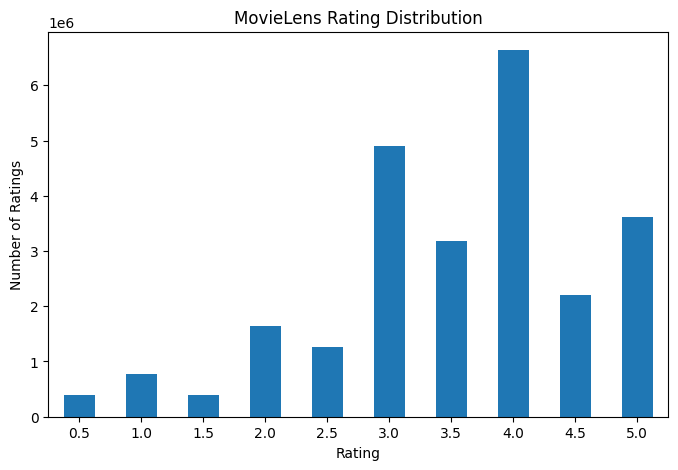

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
rating_counts.plot(kind="bar")
plt.title("MovieLens Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.show()

In [33]:
ratings_per_movie = ratings.groupby("movieId")["rating"].count().sort_values(ascending=False)
ratings_per_movie.head(10)

movieId
356     81491
318     81482
296     79672
593     74127
2571    72674
260     68717
480     64144
527     60411
110     59184
2959    58773
Name: rating, dtype: int64

In [34]:
ratings_per_movie.describe()

count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
25%          2.000000
50%          6.000000
75%         36.000000
max      81491.000000
Name: rating, dtype: float64

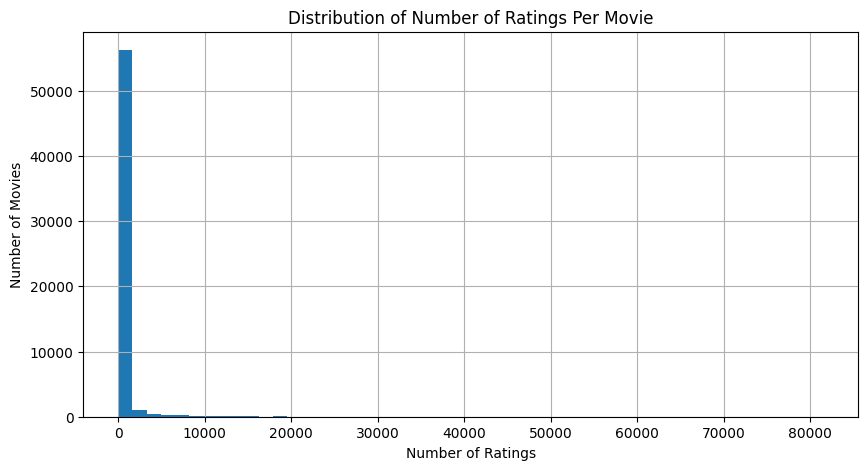

In [35]:
plt.figure(figsize=(10, 5))
ratings_per_movie.hist(bins=50)
plt.title("Distribution of Number of Ratings Per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

In [36]:
movies_with_few_ratings = (ratings_per_movie < 10).sum()
total_rated_movies = ratings_per_movie.shape[0]

print("Movies with fewer than 10 ratings:", movies_with_few_ratings)
print("Total rated movies:", total_rated_movies)
print("Percentage with fewer than 10 ratings:", movies_with_few_ratings / total_rated_movies * 100)

Movies with fewer than 10 ratings: 34717
Total rated movies: 59047
Percentage with fewer than 10 ratings: 58.7955357596491


In [37]:
ratings_per_movie_df = ratings_per_movie.reset_index()
ratings_per_movie_df.columns = ["movieId", "rating_count"]
ratings_per_movie_df.head()

,movieId,rating_count
0,356,81491
1,318,81482
2,296,79672
3,593,74127
4,2571,72674


In [38]:
movie_rating_counts = movies.merge(ratings_per_movie_df, on="movieId", how="left")
movie_rating_counts.head()

,movieId,title,genres,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,57309.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,24228.0
2,3,Grumpier Old Men (1995),Comedy|Romance,11804.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2523.0
4,5,Father of the Bride Part II (1995),Comedy,11714.0


In [39]:
movie_rating_counts.sort_values("rating_count", ascending=False).head(10)

,movieId,title,genres,rating_count
351,356,Forrest Gump (1994),Comedy|Drama|Romance|War,81491.0
314,318,"Shawshank Redemption, The (1994)",Crime|Drama,81482.0
292,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,79672.0
585,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,74127.0
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,72674.0
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,68717.0
475,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,64144.0
522,527,Schindler's List (1993),Drama|War,60411.0
108,110,Braveheart (1995),Action|Drama|War,59184.0
2867,2959,Fight Club (1999),Action|Crime|Drama|Thriller,58773.0


In [40]:
movie_rating_counts["rating_count"].isna().sum()

np.int64(3376)

In [41]:
ratings_per_user = ratings.groupby("userId")["rating"].count().sort_values(ascending=False)
ratings_per_user.head(10)

userId
72315     32202
80974      9178
137293     8913
33844      7919
20055      7488
109731     6647
92046      6564
49403      6553
30879      5693
115102     5649
Name: rating, dtype: int64

In [42]:
ratings_per_user.describe()

count    162541.000000
mean        153.807932
std         268.047590
min          20.000000
25%          36.000000
50%          71.000000
75%         162.000000
max       32202.000000
Name: rating, dtype: float64

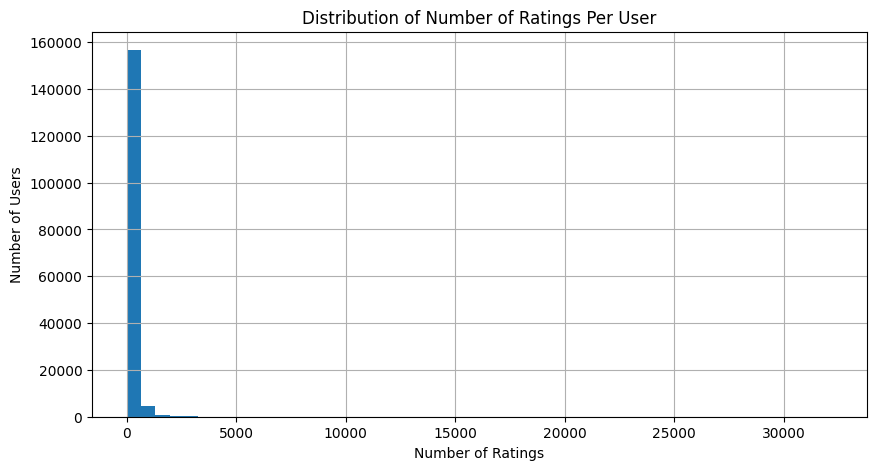

In [43]:
plt.figure(figsize=(10, 5))
ratings_per_user.hist(bins=50)
plt.title("Distribution of Number of Ratings Per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

In [44]:
users_with_few_ratings = (ratings_per_user < 10).sum()
total_users = ratings_per_user.shape[0]

print("Users with fewer than 10 ratings:", users_with_few_ratings)
print("Total users:", total_users)
print("Percentage with fewer than 10 ratings:", users_with_few_ratings / total_users * 100)

Users with fewer than 10 ratings: 0
Total users: 162541
Percentage with fewer than 10 ratings: 0.0


In [45]:
movies["genres"].head()

0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
Name: genres, dtype: str

In [46]:
movies["genre_list"] = movies["genres"].str.split("|")
movies[["title", "genres", "genre_list"]].head()

,title,genres,genre_list
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,Jumanji (1995),Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]"
2,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]"
3,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
4,Father of the Bride Part II (1995),Comedy,[Comedy]


In [47]:
all_genres = movies["genre_list"].explode()
all_genres.head(10)

0    Adventure
0    Animation
0     Children
0       Comedy
0      Fantasy
1    Adventure
1     Children
1      Fantasy
2       Comedy
2      Romance
Name: genre_list, dtype: str

In [48]:
genre_counts = all_genres.value_counts()
genre_counts

genre_list
Drama                 25606
Comedy                16870
Thriller               8654
Romance                7719
Action                 7348
Horror                 5989
Documentary            5605
Crime                  5319
(no genres listed)     5062
Adventure              4145
Sci-Fi                 3595
Children               2935
Animation              2929
Mystery                2925
Fantasy                2731
War                    1874
Western                1399
Musical                1054
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

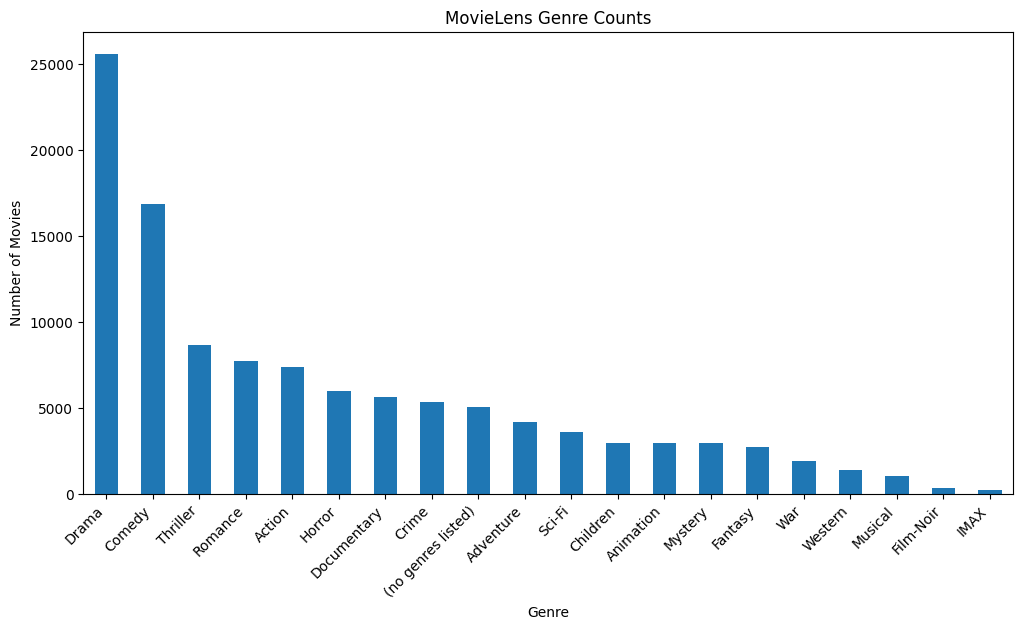

In [49]:
plt.figure(figsize=(12, 6))
genre_counts.plot(kind="bar")
plt.title("MovieLens Genre Counts")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha="right")
plt.show()

In [50]:
no_genres_movies = movies[movies["genres"] == "(no genres listed)"]
no_genres_movies.head()

,movieId,title,genres,genre_list
15881,83773,Away with Words (San tiao ren) (1999),(no genres listed),[(no genres listed)]
16060,84768,Glitterbug (1994),(no genres listed),[(no genres listed)]
16351,86493,"Age of the Earth, The (A Idade da Terra) (1980)",(no genres listed),[(no genres listed)]
16491,87061,Trails (Veredas) (1978),(no genres listed),[(no genres listed)]
17404,91246,Milky Way (Tejút) (2007),(no genres listed),[(no genres listed)]


In [51]:
print("Movies with no listed genres:", no_genres_movies.shape[0])
print("Total movies:", movies.shape[0])
print("Percentage with no listed genres:", no_genres_movies.shape[0] / movies.shape[0] * 100)

Movies with no listed genres: 5062
Total movies: 62423
Percentage with no listed genres: 8.109190522723996


In [52]:
no_genres_movies.sample(10, random_state=42)

,movieId,title,genres,genre_list
23086,116955,The Wild World of Lydia Lunch (1983),(no genres listed),[(no genres listed)]
42442,163879,Straight Is the Way (1934),(no genres listed),[(no genres listed)]
44680,168746,Escape from the Newsroom (2002),(no genres listed),[(no genres listed)]
36999,151667,Romance on the Run (1938),(no genres listed),[(no genres listed)]
55216,191403,"New Neighbors, Old Fights",(no genres listed),[(no genres listed)]
47528,174741,Spicebush (2005),(no genres listed),[(no genres listed)]
47254,174129,Gymnasium Exercises and Drill at Newport Train...,(no genres listed),[(no genres listed)]
45272,169986,Beata ignoranza (2017),(no genres listed),[(no genres listed)]
34329,145156,The Perfect Husband (2004),(no genres listed),[(no genres listed)]
43766,166790,My Future Love (2016),(no genres listed),[(no genres listed)]


## Initial MovieLens EDA Findings

### Dataset Structure

The MovieLens data includes movie metadata, external ID links, and user rating interactions.

The main files inspected so far are:

- `movies.csv`: movie titles and genres
- `links.csv`: MovieLens IDs mapped to IMDb and TMDB IDs
- `ratings.csv`: user-movie rating interactions

### Data Quality Observations

- `movies.csv` and `links.csv` have matching movie-level rows.
- `movieId` is the key that connects MovieLens tables.
- Some `tmdbId` values may be missing, which could affect future TMDB metadata enrichment.
- No duplicate `movieId` values were found in the inspected movie and links tables.
- The ratings sample did not show missing values or duplicate user-movie ratings.

### Ratings Observations

- Ratings use a 0.5 to 5.0 scale.
- Higher ratings appear common, which may reflect selection bias.
- The full ratings table is large, so memory-aware loading is important.
- Rating timestamps were converted into readable datetimes for time-based analysis.

### Popularity And Sparsity Observations

- Some movies have many ratings, while many movies have few ratings.
- This long-tail pattern creates item cold-start challenges.
- Users also vary in activity level, creating user cold-start challenges.

### Genre Observations

- Genres are stored as multi-label strings separated by `|`.
- Some movies have `(no genres listed)`, which means genre metadata is missing.
- Genres are useful for a simple content-based recommender, but they are limited because broad genres do not fully describe movie meaning.

### Next Questions

- How should we handle movies with missing genres?
- How should we connect MovieLens movies to richer TMDB metadata?
- What subset of data should we use first for a simple content-based recommender?